# Inventory Replenishment Agent
## Group Exercise — Agentic AI in Supply Chain



## Design Summary

**Agent goal:** Minimize stockouts and total inventory-related cost while maintaining service reliability.

**Inputs:** Daily demand history, current stock, lead time, service level, minimum order quantity, holding cost, and stockout cost for each SKU.

**Outputs:** For each SKU each day, the agent decides whether to place an order or wait. If it orders, it decides the order quantity.

**Guardrails:**
- respect `min_order_qty`
- account for lead time
- use service level to determine safety stock
- avoid unrealistic over-ordering with an order cap
- balance holding cost against stockout risk

**Metrics:** Stockout units, stockout days, fill rate, holding cost, stockout cost, and total cost.

**Ethics and trust:** Better replenishment decisions reduce preventable stockouts for customers while protecting business resources through cost-aware ordering. Daily logs make the system more transparent and auditable.


## 1. Imports and Setup


In [58]:
import os
from math import ceil
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    from scipy.stats import norm
except ImportError:
    !pip -q install scipy
    from scipy.stats import norm

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 200)


## 2. Load the Required CSV Files


In [59]:
SALES_FILE = "sales.csv"
INVENTORY_FILE = "inventory.csv"
PARAMS_FILE = "params.csv"

for fp in [SALES_FILE, INVENTORY_FILE, PARAMS_FILE]:
    if not os.path.exists(fp):
        raise FileNotFoundError(f"Missing required file: {fp}")

sales = pd.read_csv(SALES_FILE)
inventory = pd.read_csv(INVENTORY_FILE)
params = pd.read_csv(PARAMS_FILE)

print("sales.csv")
display(sales.head())

print("inventory.csv")
display(inventory.head())

print("params.csv")
display(params.head())


sales.csv


,date,sku,qty_sold
0,2024-01-01,SKU_A,15
1,2024-01-01,SKU_B,7
2,2024-01-02,SKU_A,13
3,2024-01-02,SKU_B,10
4,2024-01-03,SKU_A,12


inventory.csv


,sku,opening_stock
0,SKU_A,130
1,SKU_B,115


params.csv


,sku,unit_cost,holding_cost_per_day,stockout_cost,lead_time_days,min_order_qty,service_level
0,SKU_A,10.0,0.05,5.0,5,25,0.95
1,SKU_B,8.0,0.04,6.0,7,20,0.97


## 3. Validate and Prepare Data

This section:
- checks required columns
- converts `date` to datetime
- aggregates daily demand per SKU
- fills missing date/SKU combinations with zero demand


In [60]:
required_sales = {"date", "sku", "qty_sold"}
required_inventory = {"sku", "opening_stock"}
required_params = {
    "sku", "unit_cost", "holding_cost_per_day", "stockout_cost",
    "lead_time_days", "min_order_qty", "service_level"
}

assert required_sales.issubset(sales.columns), f"sales.csv must include {required_sales}"
assert required_inventory.issubset(inventory.columns), f"inventory.csv must include {required_inventory}"
assert required_params.issubset(params.columns), f"params.csv must include {required_params}"

sales["date"] = pd.to_datetime(sales["date"])
sales = sales.groupby(["date", "sku"], as_index=False)["qty_sold"].sum()

all_dates = pd.date_range(sales["date"].min(), sales["date"].max(), freq="D")
all_skus = sorted(sales["sku"].unique().tolist())
full_index = pd.MultiIndex.from_product([all_dates, all_skus], names=["date", "sku"])

sales = (
    sales.set_index(["date", "sku"])
    .reindex(full_index, fill_value=0)
    .reset_index()
)

missing_inventory = set(sales["sku"].unique()) - set(inventory["sku"].unique())
missing_params = set(sales["sku"].unique()) - set(params["sku"].unique())

assert not missing_inventory, f"Missing inventory rows for SKUs: {missing_inventory}"
assert not missing_params, f"Missing params rows for SKUs: {missing_params}"
assert (params["lead_time_days"] > 0).all(), "lead_time_days must be > 0"
assert (params["min_order_qty"] > 0).all(), "min_order_qty must be > 0"
assert ((params["service_level"] > 0) & (params["service_level"] < 1)).all(), "service_level must be between 0 and 1"

print(f"Date range: {sales['date'].min().date()} to {sales['date'].max().date()}")
print(f"Days: {sales['date'].nunique()} | SKUs: {sales['sku'].nunique()}")
display(sales.head(10))


Date range: 2024-01-01 to 2024-03-30
Days: 90 | SKUs: 2


,date,sku,qty_sold
0,2024-01-01,SKU_A,15
1,2024-01-01,SKU_B,7
2,2024-01-02,SKU_A,13
3,2024-01-02,SKU_B,10
4,2024-01-03,SKU_A,12
5,2024-01-03,SKU_B,9
6,2024-01-04,SKU_A,13
7,2024-01-04,SKU_B,3
8,2024-01-05,SKU_A,13
9,2024-01-05,SKU_B,10


## 4. Demand Forecasting with EWMA

For each SKU, use an exponentially weighted moving average forecast:

\[
F_t = \alpha D_{t-1} + (1-\alpha)F_{t-1}
\]




In [61]:
ALPHA = 0.30

def add_ewma_forecast(df: pd.DataFrame, alpha: float = 0.30) -> pd.DataFrame:
    df = df.sort_values(["sku", "date"]).copy()
    pieces = []

    for sku, g in df.groupby("sku"):
        g = g.copy().sort_values("date")
        demand = g["qty_sold"].to_numpy(dtype=float)

        forecast = np.zeros(len(g), dtype=float)
        forecast[0] = demand[0]

        for t in range(1, len(g)):
            forecast[t] = alpha * demand[t - 1] + (1 - alpha) * forecast[t - 1]

        g["forecast"] = forecast
        g["forecast_error"] = g["qty_sold"] - g["forecast"]
        pieces.append(g)

    return pd.concat(pieces, ignore_index=True)

sales_fcst = add_ewma_forecast(sales, alpha=ALPHA)
display(sales_fcst.head(10))


,date,sku,qty_sold,forecast,forecast_error
0,2024-01-01,SKU_A,15,15.000000,0.000000
1,2024-01-02,SKU_A,13,15.000000,-2.000000
2,2024-01-03,SKU_A,12,14.400000,-2.400000
3,2024-01-04,SKU_A,13,13.680000,-0.680000
4,2024-01-05,SKU_A,13,13.476000,-0.476000
5,2024-01-06,SKU_A,10,13.333200,-3.333200
6,2024-01-07,SKU_A,12,12.333240,-0.333240
7,2024-01-08,SKU_A,12,12.233268,-0.233268
8,2024-01-09,SKU_A,14,12.163288,1.836712
9,2024-01-10,SKU_A,14,12.714301,1.285699


## 5. Safety Stock and Reorder Parameters

Safety stock formula:

\[
SafetyStock = z \cdot \sigma_{error} \cdot \sqrt{L}
\]

where:
- \( z \) comes from the service level
- \( \sigma_{error} \) is forecast error standard deviation
- \( L \) is lead time


In [62]:
def build_sku_params(sales_fcst: pd.DataFrame, params: pd.DataFrame) -> pd.DataFrame:
    rows = []

    for sku, g in sales_fcst.groupby("sku"):
        sigma_error = g["forecast_error"].std(ddof=1)
        if pd.isna(sigma_error):
            sigma_error = 0.0

        p = params.loc[params["sku"] == sku].iloc[0]
        z_value = float(norm.ppf(p["service_level"]))

        rows.append({
            "sku": sku,
            "sigma_error": float(sigma_error),
            "z_value": z_value
        })

    stats = pd.DataFrame(rows)
    out = params.merge(stats, on="sku", how="left")
    return out

sku_params = build_sku_params(sales_fcst, params)
display(sku_params)


,sku,unit_cost,holding_cost_per_day,stockout_cost,lead_time_days,min_order_qty,service_level,sigma_error,z_value
0,SKU_A,10.0,0.05,5.0,5,25,0.95,2.055731,1.644854
1,SKU_B,8.0,0.04,6.0,7,20,0.97,3.552738,1.880794


## 6. Define Baseline and Agent Policies

- **Baseline policy:** fixed reorder point based on average demand and a simple fixed restocking rule
- **Agent policy:** forecast-based reorder point and target stock using EWMA

Both policies use the exact same simulation engine.


In [63]:
avg_demand_map = sales_fcst.groupby("sku")["qty_sold"].mean().to_dict()
print("Average daily demand by SKU:", avg_demand_map)


Average daily demand by SKU: {'SKU_A': 12.933333333333334, 'SKU_B': 10.0}


## 7. Simulation Engine

Each day, for each SKU, the simulator:
1. receives any purchase orders arriving that day
2. observes actual demand
3. fulfills what it can from on-hand stock
4. records unmet demand / stockouts
5. computes policy-specific reorder logic
6. places an order or waits
7. logs the rationale


In [64]:
def simulate_policy(
    sales_fcst: pd.DataFrame,
    sku_params: pd.DataFrame,
    inventory_df: pd.DataFrame,
    policy_name: str = "agent",
    review_period_days: int = 1,
):
    assert policy_name in {"agent", "baseline"}

    df = sales_fcst.copy().sort_values(["date", "sku"])
    dates = sorted(df["date"].unique())
    skus = sorted(df["sku"].unique())

    param_map = sku_params.set_index("sku").to_dict(orient="index")
    on_hand = inventory_df.set_index("sku")["opening_stock"].astype(float).to_dict()
    pipeline = {sku: [] for sku in skus}

    log_rows = []

    total_demand = 0.0
    total_filled = 0.0
    total_stockout_units = 0.0
    stockout_days = 0
    total_holding_cost = 0.0
    total_stockout_cost = 0.0

    for current_date in dates:
        day_df = df[df["date"] == current_date].sort_values("sku")

        for _, row in day_df.iterrows():
            sku = row["sku"]
            demand = float(row["qty_sold"])
            forecast = float(row["forecast"])
            p = param_map[sku]

            lead_time = int(p["lead_time_days"])
            min_order_qty = int(p["min_order_qty"])
            sigma_error = float(p["sigma_error"])
            z_value = float(p["z_value"])
            holding_cost_per_day = float(p["holding_cost_per_day"])
            stockout_cost = float(p["stockout_cost"])

            # Receive arrivals
            arrivals_today = 0.0
            remaining_pipeline = []
            for arrival_date, qty in pipeline[sku]:
                if pd.Timestamp(arrival_date) == pd.Timestamp(current_date):
                    arrivals_today += qty
                else:
                    remaining_pipeline.append((arrival_date, qty))
            pipeline[sku] = remaining_pipeline
            on_hand[sku] += arrivals_today
            on_hand_start = on_hand[sku]

            # Fulfill demand
            filled = min(on_hand[sku], demand)
            unmet = max(demand - filled, 0.0)
            on_hand[sku] -= filled

            total_demand += demand
            total_filled += filled
            total_stockout_units += unmet
            if unmet > 0:
                stockout_days += 1

            on_order_qty_before_new_order = sum(qty for _, qty in pipeline[sku])
            safety_stock = z_value * sigma_error * np.sqrt(lead_time)
            adjusted_safety_stock = safety_stock

            avg_demand = avg_demand_map[sku]
            if policy_name == "baseline":
                reorder_point = avg_demand * lead_time + safety_stock
                target_stock = avg_demand * (lead_time + review_period_days) + safety_stock
                effective_forecast = avg_demand
                reason_prefix = "Baseline fixed-demand policy"
            else:
                agent_buffer_days = 1
                agent_safety_multiplier = 1.10

                effective_forecast = max(forecast, avg_demand)
                adjusted_safety_stock = safety_stock * agent_safety_multiplier

                reorder_point = effective_forecast * lead_time + adjusted_safety_stock
                target_stock = effective_forecast * (lead_time + review_period_days) + adjusted_safety_stock
                reason_prefix = "Agent forecast-based policy"

            inventory_position = on_hand[sku] + on_order_qty_before_new_order

            action = "WAIT"
            order_qty = 0
            order_cap = max(min_order_qty, int(ceil(3 * max(forecast, 1) * (lead_time + review_period_days))))
            reason = f"{reason_prefix}: inventory position covers projected need."

            if inventory_position <= reorder_point:
                raw_order = max(target_stock - inventory_position, 0)
                proposed_order = max(min_order_qty, int(ceil(raw_order)))
                order_qty = min(proposed_order, order_cap)
                action = "ORDER"

                arrival_date = pd.Timestamp(current_date) + pd.Timedelta(days=lead_time)
                pipeline[sku].append((arrival_date, order_qty))

                reason = (
                    f"{reason_prefix}: ordered because inventory_position={inventory_position:.2f} "
                    f"<= reorder_point={reorder_point:.2f}. "
                    f"Effective_forecast={effective_forecast:.2f}, "
                    f"Target_stock={target_stock:.2f}, min_order_qty={min_order_qty}, "
                    f"order_cap={order_cap}."
                )

            daily_holding_cost = on_hand[sku] * holding_cost_per_day
            daily_stockout_cost = unmet * stockout_cost

            total_holding_cost += daily_holding_cost
            total_stockout_cost += daily_stockout_cost

            log_rows.append({
                "date": pd.Timestamp(current_date),
                "sku": sku,
                "policy": policy_name,
                "demand": demand,
                "forecast": round(forecast, 4),
                "effective_forecast": round(effective_forecast, 4),
                "arrivals_today": arrivals_today,
                "on_hand_start": round(on_hand_start, 4),
                "filled_units": filled,
                "unmet_units": unmet,
                "on_hand_end": round(on_hand[sku], 4),
                "on_order_qty": round(sum(qty for _, qty in pipeline[sku]), 4),
                "inventory_position": round(inventory_position, 4),
                "safety_stock": round(adjusted_safety_stock if policy_name == "agent" else safety_stock, 4),
                "reorder_point": round(reorder_point, 4),
                "target_stock": round(target_stock, 4),
                "order_cap": order_cap,
                "action": action,
                "order_qty": order_qty,
                "daily_holding_cost": round(daily_holding_cost, 4),
                "daily_stockout_cost": round(daily_stockout_cost, 4),
                "reason": reason,
            })

    fill_rate = total_filled / total_demand if total_demand > 0 else 0.0
    total_cost = total_holding_cost + total_stockout_cost

    metrics = {
        "policy": policy_name,
        "total_demand": round(total_demand, 4),
        "total_filled": round(total_filled, 4),
        "stockout_units": round(total_stockout_units, 4),
        "stockout_days": int(stockout_days),
        "fill_rate": round(fill_rate, 4),
        "holding_cost": round(total_holding_cost, 4),
        "stockout_cost": round(total_stockout_cost, 4),
        "total_cost": round(total_cost, 4),
    }

    logs = pd.DataFrame(log_rows)
    return metrics, logs


## 8. Run Baseline and Agent Simulations


In [65]:
baseline_metrics, baseline_log = simulate_policy(
    sales_fcst=sales_fcst,
    sku_params=sku_params,
    inventory_df=inventory,
    policy_name="baseline",
    review_period_days=1,
)

agent_metrics, agent_log = simulate_policy(
    sales_fcst=sales_fcst,
    sku_params=sku_params,
    inventory_df=inventory,
    policy_name="agent",
    review_period_days=1,
)

print("Baseline metrics:", baseline_metrics)
print("Agent metrics:", agent_metrics)


Baseline metrics: {'policy': 'baseline', 'total_demand': 2064.0, 'total_filled': 2054.0, 'stockout_units': 10.0, 'stockout_days': 2, 'fill_rate': 0.9952, 'holding_cost': 221.31, 'stockout_cost': 60.0, 'total_cost': 281.31}
Agent metrics: {'policy': 'agent', 'total_demand': 2064.0, 'total_filled': 2064.0, 'stockout_units': 0.0, 'stockout_days': 0, 'fill_rate': 1.0, 'holding_cost': 254.91, 'stockout_cost': 0.0, 'total_cost': 254.91}


## 9. Daily Agent Log Sample


In [66]:
display(agent_log.head(20))


,date,sku,policy,demand,forecast,effective_forecast,arrivals_today,on_hand_start,filled_units,unmet_units,on_hand_end,on_order_qty,inventory_position,safety_stock,reorder_point,target_stock,order_cap,action,order_qty,daily_holding_cost,daily_stockout_cost,reason
0,2024-01-01,SKU_A,agent,15.0,15.0000,15.0000,0.0,130.0,15.0,0.0,115.0,0,115.0,8.3171,83.3171,98.3171,270,WAIT,0,5.75,0.0,Agent forecast-based policy: inventory positio...
1,2024-01-01,SKU_B,agent,7.0,7.0000,10.0000,0.0,115.0,7.0,0.0,108.0,0,108.0,19.4467,89.4467,99.4467,168,WAIT,0,4.32,0.0,Agent forecast-based policy: inventory positio...
2,2024-01-02,SKU_A,agent,13.0,15.0000,15.0000,0.0,115.0,13.0,0.0,102.0,0,102.0,8.3171,83.3171,98.3171,270,WAIT,0,5.10,0.0,Agent forecast-based policy: inventory positio...
3,2024-01-02,SKU_B,agent,10.0,7.0000,10.0000,0.0,108.0,10.0,0.0,98.0,0,98.0,19.4467,89.4467,99.4467,168,WAIT,0,3.92,0.0,Agent forecast-based policy: inventory positio...
4,2024-01-03,SKU_A,agent,12.0,14.4000,14.4000,0.0,102.0,12.0,0.0,90.0,0,90.0,8.3171,80.3171,94.7171,260,WAIT,0,4.50,0.0,Agent forecast-based policy: inventory positio...
5,2024-01-03,SKU_B,agent,9.0,7.9000,10.0000,0.0,98.0,9.0,0.0,89.0,20,89.0,19.4467,89.4467,99.4467,190,ORDER,20,3.56,0.0,Agent forecast-based policy: ordered because i...
6,2024-01-04,SKU_A,agent,13.0,13.6800,13.6800,0.0,90.0,13.0,0.0,77.0,0,77.0,8.3171,76.7171,90.3971,247,WAIT,0,3.85,0.0,Agent forecast-based policy: inventory positio...
7,2024-01-04,SKU_B,agent,3.0,8.2300,10.0000,0.0,89.0,3.0,0.0,86.0,20,106.0,19.4467,89.4467,99.4467,198,WAIT,0,3.44,0.0,Agent forecast-based policy: inventory positio...
8,2024-01-05,SKU_A,agent,13.0,13.4760,13.4760,0.0,77.0,13.0,0.0,64.0,26,64.0,8.3171,75.6971,89.1731,243,ORDER,26,3.20,0.0,Agent forecast-based policy: ordered because i...
9,2024-01-05,SKU_B,agent,10.0,6.6610,10.0000,0.0,86.0,10.0,0.0,76.0,20,96.0,19.4467,89.4467,99.4467,160,WAIT,0,3.04,0.0,Agent forecast-based policy: inventory positio...


## 10. Order Decision Log Sample


In [67]:
agent_orders = agent_log[agent_log["action"] == "ORDER"].copy()
display(agent_orders.head(20))


,date,sku,policy,demand,forecast,effective_forecast,arrivals_today,on_hand_start,filled_units,unmet_units,on_hand_end,on_order_qty,inventory_position,safety_stock,reorder_point,target_stock,order_cap,action,order_qty,daily_holding_cost,daily_stockout_cost,reason
5,2024-01-03,SKU_B,agent,9.0,7.9000,10.0000,0.0,98.0,9.0,0.0,89.0,20,89.0,19.4467,89.4467,99.4467,190,ORDER,20,3.56,0.0,Agent forecast-based policy: ordered because i...
8,2024-01-05,SKU_A,agent,13.0,13.4760,13.4760,0.0,77.0,13.0,0.0,64.0,26,64.0,8.3171,75.6971,89.1731,243,ORDER,26,3.20,0.0,Agent forecast-based policy: ordered because i...
11,2024-01-06,SKU_B,agent,11.0,7.6627,10.0000,0.0,76.0,11.0,0.0,65.0,40,85.0,19.4467,89.4467,99.4467,184,ORDER,20,2.60,0.0,Agent forecast-based policy: ordered because i...
12,2024-01-07,SKU_A,agent,12.0,12.3332,12.9333,0.0,54.0,12.0,0.0,42.0,51,68.0,8.3171,72.9838,85.9171,222,ORDER,25,2.10,0.0,Agent forecast-based policy: ordered because i...
16,2024-01-09,SKU_A,agent,14.0,12.1633,12.9333,0.0,30.0,14.0,0.0,16.0,76,67.0,8.3171,72.9838,85.9171,219,ORDER,25,0.80,0.0,Agent forecast-based policy: ordered because i...
17,2024-01-09,SKU_B,agent,9.0,7.5453,10.0000,0.0,51.0,9.0,0.0,42.0,60,82.0,19.4467,89.4467,99.4467,182,ORDER,20,1.68,0.0,Agent forecast-based policy: ordered because i...
20,2024-01-11,SKU_A,agent,16.0,13.1000,13.1000,0.0,28.0,16.0,0.0,12.0,75,62.0,8.3171,73.8171,86.9172,236,ORDER,25,0.60,0.0,Agent forecast-based policy: ordered because i...
21,2024-01-11,SKU_B,agent,9.0,6.7872,10.0000,0.0,58.0,9.0,0.0,49.0,60,89.0,19.4467,89.4467,99.4467,163,ORDER,20,1.96,0.0,Agent forecast-based policy: ordered because i...
22,2024-01-12,SKU_A,agent,11.0,13.9700,13.9700,25.0,37.0,11.0,0.0,26.0,75,76.0,8.3171,78.1671,92.1371,252,ORDER,25,1.30,0.0,Agent forecast-based policy: ordered because i...
25,2024-01-13,SKU_B,agent,7.0,9.7157,10.0000,20.0,54.0,7.0,0.0,47.0,60,87.0,19.4467,89.4467,99.4467,234,ORDER,20,1.88,0.0,Agent forecast-based policy: ordered because i...


## 11. Metric Definitions

- **Stockout units:** total unmet demand across the simulation
- **Stockout days:** number of day-SKU combinations with unmet demand
- **Fill rate:** total filled demand divided by total demand
- **Holding cost:** ending inventory times holding cost per day
- **Stockout cost:** unmet demand times stockout cost
- **Total cost:** holding cost plus stockout cost


## 12. Evaluation: Baseline vs Agent


In [68]:
metrics_summary = pd.DataFrame([baseline_metrics, agent_metrics])
display(metrics_summary)


,policy,total_demand,total_filled,stockout_units,stockout_days,fill_rate,holding_cost,stockout_cost,total_cost
0,baseline,2064.0,2054.0,10.0,2,0.9952,221.31,60.0,281.31
1,agent,2064.0,2064.0,0.0,0,1.0000,254.91,0.0,254.91


In [69]:
baseline_total_cost = metrics_summary.loc[metrics_summary["policy"] == "baseline", "total_cost"].iloc[0]
agent_total_cost = metrics_summary.loc[metrics_summary["policy"] == "agent", "total_cost"].iloc[0]

baseline_fill_rate = metrics_summary.loc[metrics_summary["policy"] == "baseline", "fill_rate"].iloc[0]
agent_fill_rate = metrics_summary.loc[metrics_summary["policy"] == "agent", "fill_rate"].iloc[0]

print("Comparison Summary:")
print(f"Baseline total cost: {baseline_total_cost}")
print(f"Agent total cost: {agent_total_cost}")
print(f"Baseline fill rate: {baseline_fill_rate}")
print(f"Agent fill rate: {agent_fill_rate}")

if agent_total_cost < baseline_total_cost and agent_fill_rate >= baseline_fill_rate:
    print("\nAgent outperformed the baseline on both cost and service.")
elif agent_fill_rate > baseline_fill_rate:
    print("\\nAgent improved service, but cost trade-offs should be reviewed.")
else:
    print("\\nBaseline remained competitive; further tuning may be needed.")

Comparison Summary:
Baseline total cost: 281.31
Agent total cost: 254.91
Baseline fill rate: 0.9952
Agent fill rate: 1.0

Agent outperformed the baseline on both cost and service.


## 13. Save Output Files


In [70]:
os.makedirs("outputs", exist_ok=True)

baseline_log.to_csv("outputs/baseline_daily_log.csv", index=False)
agent_log.to_csv("outputs/agent_daily_log.csv", index=False)
metrics_summary.to_csv("outputs/metrics_summary.csv", index=False)

print("Saved:")
print("- outputs/baseline_daily_log.csv")
print("- outputs/agent_daily_log.csv")
print("- outputs/metrics_summary.csv")


Saved:
- outputs/baseline_daily_log.csv
- outputs/agent_daily_log.csv
- outputs/metrics_summary.csv


## 14. Visualizations


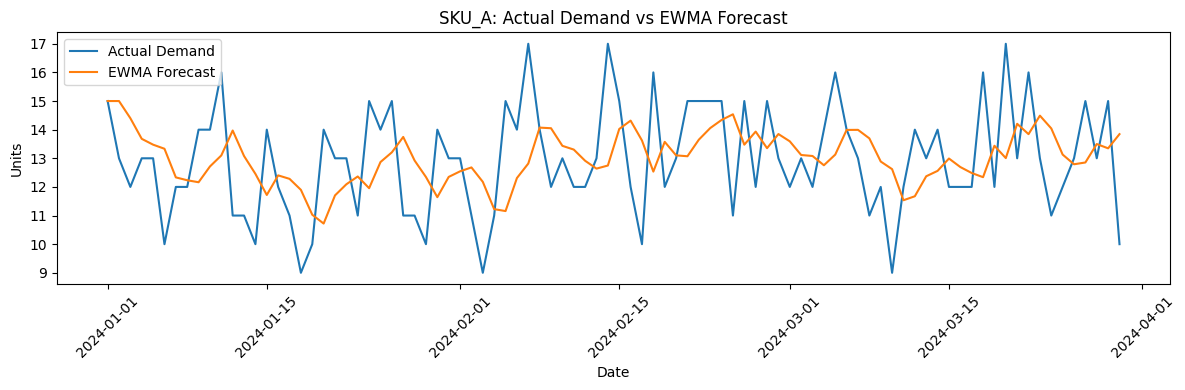

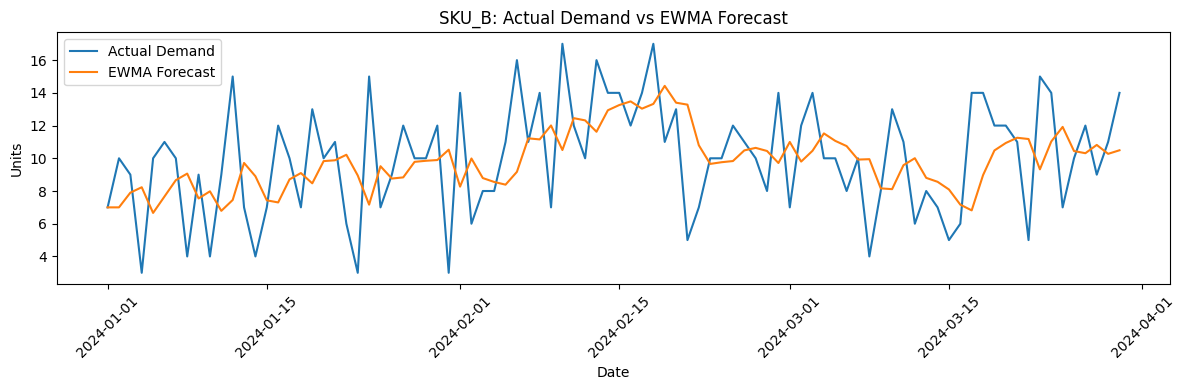

In [71]:
os.makedirs("outputs", exist_ok=True)

for sku, g in sales_fcst.groupby("sku"):
    g = g.sort_values("date")
    plt.figure(figsize=(12, 4))
    plt.plot(g["date"], g["qty_sold"], label="Actual Demand")
    plt.plot(g["date"], g["forecast"], label="EWMA Forecast")
    plt.title(f"{sku}: Actual Demand vs EWMA Forecast")
    plt.xlabel("Date")
    plt.ylabel("Units")
    plt.legend()
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.savefig(f"outputs/{sku}_demand_vs_forecast.png")
    plt.show()


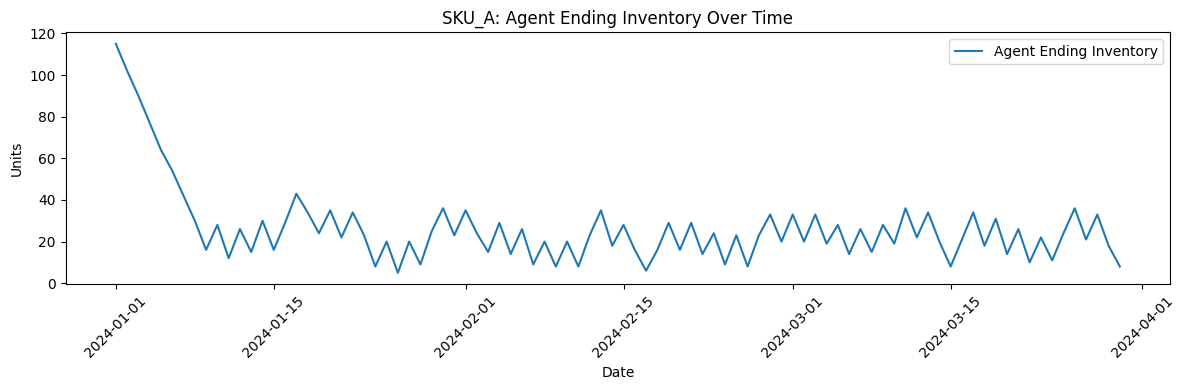

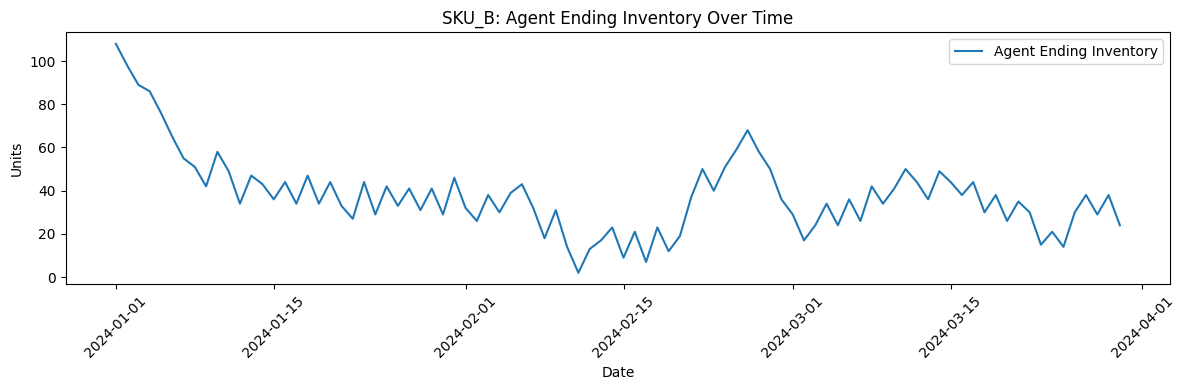

In [72]:
for sku, g in agent_log.groupby("sku"):
    g = g.sort_values("date")
    plt.figure(figsize=(12, 4))
    plt.plot(g["date"], g["on_hand_end"], label="Agent Ending Inventory")
    plt.title(f"{sku}: Agent Ending Inventory Over Time")
    plt.xlabel("Date")
    plt.ylabel("Units")
    plt.legend()
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.savefig(f"outputs/{sku}_agent_inventory.png")
    plt.show()


## 15. Business Trade-off Reflection

The agent aims to reduce stockouts by ordering when projected inventory risk exceeds the reorder threshold.  
A higher service level increases safety stock, which usually improves fill rate but can raise holding cost.  
A lower service level reduces inventory held, but increases the chance of stockouts and lost service.

In practice, the right balance depends on how expensive stockouts are relative to carrying inventory. There will always be tension between how much inventory is being carried.


## 16. Scaling Note

A production version of this agent could run as a scheduled cloud batch job each day.  
It would load fresh sales and inventory data, recompute forecasts, and write replenishment recommendations to a database or dashboard.

For monitoring, the business should track:
- fill rate
- forecast error
- stockout spikes
- unusual order quantities

For reliability, the system should validate inputs, handle missing data safely, and log every decision for auditability.

For cost control, the business could add caps on order size, working-capital limits, and alerts when holding cost rises too high.


## 17. Conclusion

For this Colab we:

Compared with the baseline policy on this 90-day, 2-SKU dataset:
- Fill rate improved from 0.9952 to 1.0000
- Stockout units dropped from 10 to 0
- Total cost decreased from 281.31 to 254.91

These results show that a forecast-based replenishment policy can improve service reliability while also lowering total inventory-related cost when tuned appropriately.
